# Filtering TM/TR CDF plot (stencil 0617 dsub)

Based on 0616. The standalone EP/ER cell is merged into the DR cell: the WD bars are drawn once,
with DR on the right axis and per-timer eps_P/eps_R threshold arrows on top of each bar.
Thresholds (EP_THRESHOLD / ER_THRESHOLD) are rough placeholders -- tune by hand.

In [29]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [30]:
DATE_BASE = "20260616"
HOST_ORDER = ["cgnr6760pn2", "camd9554n1", "c920bn3"]
SHUFFLE_SELECT = "shuffle2"

# Previous 0614/root examples, kept for audit and intentionally not used:
# /astrum/home/hpchzy/code/data/20260614/c920bn3/output_filt/full-stencil-0614-c920bn3/shuffle0
# Reason: 0614 stencil harness used INSITU_SUB_ASM/output_filt and did not have tvkern-style dsub/effective NSPV/run-log handling.

RUN_ROOT_OVERRIDES = {}


def latest_run_root(host, shuffle_select=SHUFFLE_SELECT):
    if host in RUN_ROOT_OVERRIDES:
        return RUN_ROOT_OVERRIDES[host]
    base = Path(f"/astrum/home/hpchzy/code/data/{DATE_BASE}/{host}/output_stencil_filt_dsub")
    stamps = sorted([p for p in base.iterdir() if p.is_dir()]) if base.exists() else []
    for stamp in reversed(stamps):
        root = stamp / shuffle_select
        if root.exists():
            return root
    return base / "REPLACE_TIMESTAMP-stencil-dsub" / shuffle_select

RUN_ROOTS = [latest_run_root(host, SHUFFLE_SELECT).parent for host in HOST_ORDER]
DATA_FOLDERS = [latest_run_root(host, SHUFFLE_SELECT) for host in HOST_ORDER]
SHUFFLE_LABEL = "_".join(f"{host}-{Path(root).name}" for host, root in zip(HOST_ORDER, DATA_FOLDERS))

QUANTILE_DROP = 1.0
SAVE_FIG = True
OUT_DIR = Path('/astrum/home/hpchzy/code/TacVar/stencil/plots_0616_stencil_dsub')

TIMER_COLORS = {
    'cgt': '#ff7f0e',
    'clock_gettime': '#ff7f0e',
    'wtime': '#2ca02c',
    'mpi_wtime': '#2ca02c',
    'papi': '#d62728',
    'papix6': '#9467bd',
    'likwid': '#8c564b',
    'tsc': '#1f77b4',
    'tsc_fence': '#4f8dd3',
    'tsc_native': '#17becf',
    'cntvct': '#e377c2',
    'cntvcto': '#e377c2',
}

TIMER_LABELS = {
    'tsc': 'TSC',
    'tsc_fence': 'TSC_Fence',
    'tsc_native': 'TSC_Native',
    'cgt': 'clock_gettime',
    'clock_gettime': 'clock_gettime',
    'wtime': 'MPI_Wtime',
    'mpi_wtime': 'MPI_Wtime',
    'papi': 'PAPI',
    'papix6': 'PAPIx6',
    'likwid': 'LIKWID',
    'cntvct': 'CNTVCT',
    'cntvcto': 'CNTVCT',
}

KERNEL_LABELS = {
    'jacobi2d5p': '2D 5-Point Jacobi Stencil',
    'tl_f90_cg_calc_w': 'TL F90 CG',
    'gs2d5p': '2D 5-Point Gauss-Seidel',
}

HOST_LABELS = {
    "cgnr6760pn2": "Intel Xeon 6760P",
    "camd9554n1": "AMD EPYC 9554",
    "camd9554n2": "AMD EPYC 9554",
    "c920bn3": "Kunpeng 920B",
}

for root in DATA_FOLDERS:
    print(root)
print("host_order:", HOST_ORDER)
print("shuffle_label:", SHUFFLE_LABEL)


/astrum/home/hpchzy/code/data/20260616/cgnr6760pn2/output_stencil_filt_dsub/20260616-134358-stencil-dsub/shuffle2
/astrum/home/hpchzy/code/data/20260616/camd9554n1/output_stencil_filt_dsub/20260616-130741-stencil-dsub/shuffle2
/astrum/home/hpchzy/code/data/20260616/c920bn3/output_stencil_filt_dsub/20260616-123531-stencil-dsub/shuffle2
host_order: ['cgnr6760pn2', 'camd9554n1', 'c920bn3']
shuffle_label: cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2


In [31]:
def parse_filt_dir(path):
    m = re.match(r'(?P<prefix>.+)_np(?P<np>\d+)_size(?P<size>\d+)_nsampRatio(?P<nsampRatio>[\d.]+)_nsamp(?P<nsamp>\d+)_filt$', path.name)
    if not m:
        return None
    d = m.groupdict()
    prefix = d.pop('prefix')
    kernel = None
    timer = None
    for candidate in sorted(TIMER_LABELS, key=len, reverse=True):
        suffix = f'_{candidate}'
        if prefix.endswith(suffix):
            kernel = prefix[:-len(suffix)]
            timer = candidate
            break
    if not kernel or not timer:
        return None
    d['kernel'] = kernel
    d['timer'] = timer
    d['np'] = int(d['np'])
    d['size'] = int(d['size'])
    d['nsamp'] = int(d['nsamp'])
    d['nsampRatio'] = float(d['nsampRatio'])
    return d


def host_from_data_folder(data_folder):
    parts = Path(data_folder).parts
    if 'data' in parts:
        i = parts.index('data')
        if len(parts) > i + 2:
            return parts[i + 2]
    return Path(data_folder).name


def timer_label(timer):
    return TIMER_LABELS.get(timer, timer.upper().replace('_', '-'))


def timer_sort_key(timer):
    order = ['tsc', 'tsc_fence', 'tsc_native', 'cntvct', 'cntvcto', 'cgt', 'clock_gettime', 'wtime', 'mpi_wtime', 'papi', 'papix6', 'likwid']
    return (order.index(timer) if timer in order else len(order), timer)


def ecdf_xy(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    vals = np.sort(vals)
    if vals.size == 0:
        return vals, vals
    y = np.arange(1, vals.size + 1) / vals.size
    keep = y <= QUANTILE_DROP
    x = vals[keep]
    y = y[keep]
    if x.size:
        x = np.r_[x[0], x]
        y = np.r_[0.0, y]
    return x, y


def read_tm(tm_file):
    df = pd.read_csv(tm_file, header=None, names=['ns'])
    return df['ns'].to_numpy()


def read_tr(tr_hist_file):
    """Read tr_hist.csv as piecewise-linear CDF.

    Format: (left_edge, prob) per row; bin [t_i, t_{i+1}) has probability prob_i;
    last row is sentinel with prob=0 (right boundary).
    Returns df with cdf[i] = cumulative probability at LEFT edge of bin i,
    so plotting ns vs cdf gives a diagonal piecewise-linear CDF (not step function).
    """
    df = pd.read_csv(tr_hist_file, header=None, names=['ns', 'prob'])
    df['ns'] = pd.to_numeric(df['ns'], errors='coerce')
    df['prob'] = pd.to_numeric(df['prob'], errors='coerce')
    df = df[np.isfinite(df['ns']) & np.isfinite(df['prob'])].copy()
    df.sort_values('ns', inplace=True)
    total = df['prob'].sum()
    if total > 0:
        df['prob'] = df['prob'] / total
    cs = df['prob'].cumsum()
    # Keep bins whose LEFT edge starts below QUANTILE_DROP, plus one right-boundary row.
    left_cdf = cs.shift(1, fill_value=0.0)
    keep = left_cdf < QUANTILE_DROP
    if keep.any():
        iloc_last = df.index.get_loc(keep[keep].index[-1])
        if iloc_last + 1 < len(df):
            keep.iloc[iloc_last + 1] = True
    df = df[keep].copy()
    # cdf[i] = CDF at left edge of bin i = sum of probs of all PREVIOUS bins
    df['cdf'] = df['prob'].cumsum().shift(1, fill_value=0.0)
    return df


def collect_entries(data_folder):
    rows = []
    data_folder = Path(data_folder)
    host = host_from_data_folder(data_folder)
    for tr_hist_file in sorted(data_folder.glob('*/tr_hist.csv')):
        filt_dir = tr_hist_file.parent
        meta = parse_filt_dir(filt_dir)
        if meta is None:
            continue
        tm_file = filt_dir / 'met.csv'
        if not tm_file.exists():
            print(f'skip missing met.csv: {filt_dir}')
            continue
        rows.append({**meta, 'host': host, 'data_folder': data_folder, 'shuffle': data_folder.name, 'filt_dir': filt_dir, 'tm_file': tm_file, 'tr_hist_file': tr_hist_file})
    return pd.DataFrame(rows)

entries = pd.concat([collect_entries(p) for p in DATA_FOLDERS], ignore_index=True)
print(f'entries: {len(entries)}')
entries.sort_values(['host', 'kernel', 'np', 'size', 'timer']).head(20)
entries = entries[(entries['timer'] != 'tsc_native') & (entries['timer'] != 'cntvct')]
entries['timer'] = entries['timer'].replace('cntvcto', 'cntvct')
# entries = entries[(entries['timer'] != 'papi') & (entries['timer'] != 'cgt')]


entries: 324


# ER/EP/Wasserstein

In [32]:
from scipy.stats import wasserstein_distance


def read_float_file(path):
    try:
        text = Path(path).read_text().strip()
        return float(text) if text else np.nan
    except FileNotFoundError:
        print(f'warning: missing {path}')
        return np.nan
    except ValueError:
        print(f'warning: invalid float in {path}')
        return np.nan


def clean_hist_for_wd(hist_file, ns_col='ns', pr_col='pr'):
    df = pd.read_csv(hist_file, header=None, names=[ns_col, pr_col])
    df[ns_col] = pd.to_numeric(df[ns_col], errors='coerce')
    df[pr_col] = pd.to_numeric(df[pr_col], errors='coerce')
    df = df[np.isfinite(df[ns_col]) & np.isfinite(df[pr_col])].copy()
    df = df[df[pr_col] > 0]
    if df.empty or df[pr_col].sum() <= 0:
        return None
    return df


def wd_to_min(hist_file):
    df = clean_hist_for_wd(hist_file)
    if df is None:
        return np.nan
    ns = df['ns'].to_numpy(dtype=float)
    pr = df['pr'].to_numpy(dtype=float)
    return wasserstein_distance(ns, np.array([ns.min()]), pr, np.array([1.0]))


def read_hist_for_sampling(hist_file):
    """Read (lb, pr) histogram into (lb, rb, pr) DataFrame for quantile sampling."""
    try:
        tmp = pd.read_csv(hist_file, header=None, names=['lb', 'pr'])
    except Exception:
        return None
    tmp['lb'] = pd.to_numeric(tmp['lb'], errors='coerce')
    tmp['pr'] = pd.to_numeric(tmp['pr'], errors='coerce').fillna(0.0)
    tmp = tmp.dropna(subset=['lb']).reset_index(drop=True)
    m = ~np.isclose(tmp['pr'], 0)
    if not m.any():
        return None
    last_nz = int(np.where(m)[0][-1])
    if last_nz + 1 >= len(tmp):
        return None
    tmp = tmp.iloc[:last_nz + 2].copy()
    tmp['rb'] = tmp['lb'].shift(-1)
    tmp['lb'] = tmp['lb'].astype(np.float64)
    tmp = tmp[['lb', 'rb', 'pr']].iloc[:-1].dropna()
    return tmp if not tmp.empty else None


def sample_from_bins_quantile(tmp_df, n=1000):
    lb = tmp_df['lb'].to_numpy()
    rb = tmp_df['rb'].to_numpy()
    pr = tmp_df['pr'].to_numpy()
    pr = pr / pr.sum()
    p0 = np.r_[0, np.cumsum(pr)]
    q = (np.arange(n) + 0.5) / n
    idx = np.searchsorted(p0[1:], q, side='right')
    local_t = (q - p0[idx]) / pr[idx]
    return lb[idx] + local_t * (rb[idx] - lb[idx])


SEQ_N = 1000

summary_rows = []
for idx, row in entries.iterrows():
    filt_folder = Path(row['filt_dir'])
    ep = read_float_file(filt_folder / 'ep.out')
    er = read_float_file(filt_folder / 'er.out')
    wd = read_float_file(filt_folder / 'wd.out')
    tm_wd = wd_to_min(filt_folder / 'tm_hist.csv')
    tr_wd = wd_to_min(filt_folder / 'tr_hist.csv')
    if not np.isfinite(tm_wd) or not np.isfinite(tr_wd):
        print(f"warning: invalid histogram for Wasserstein: {filt_folder.name} tm_wd={tm_wd} tr_wd={tr_wd}")
    _tr_h = read_hist_for_sampling(filt_folder / 'tr_hist.csv')
    _tm_h = read_hist_for_sampling(filt_folder / 'tm_hist.csv')
    tr_seq = sample_from_bins_quantile(_tr_h, SEQ_N) if _tr_h is not None else None
    tm_seq = sample_from_bins_quantile(_tm_h, SEQ_N) if _tm_h is not None else None
    summary_rows.append({**row.to_dict(), 'ep': ep, 'er': er, 'wd': wd, 'tm_wd': tm_wd, 'tr_wd': tr_wd, 'tr_seq': tr_seq, 'tm_seq': tm_seq})

df = pd.DataFrame(summary_rows).reset_index(drop=True)
df.sort_values(['host', 'kernel', 'np', 'size', 'timer'], inplace=True)

df = df[~df['kernel'].str.contains('tsc')]

df[['host', 'kernel', 'timer', 'np', 'size', 'ep', 'er', 'wd', 'tm_wd', 'tr_wd']].head(20)  # tr_seq/tm_seq stored as object columns


,host,kernel,timer,np,size,ep,er,wd,tm_wd,tr_wd
185,c920bn3,gs2d5p,cgt,64,64,0.000000,0.009215,3.337688,0.000000,0.000000
191,c920bn3,gs2d5p,cntvct,64,64,0.000000,0.008100,2.874372,0.000000,0.000000
197,c920bn3,gs2d5p,papi,64,64,0.013677,0.016334,8.059296,3.239257,3.239260
203,c920bn3,gs2d5p,papix6,64,64,0.006636,0.010912,5.445226,8.734259,8.734290
209,c920bn3,gs2d5p,wtime,64,64,0.000000,0.008885,3.234171,0.000000,0.000000
181,c920bn3,gs2d5p,cgt,64,128,0.000000,0.005209,3.728643,0.000000,0.000000
187,c920bn3,gs2d5p,cntvct,64,128,0.003378,0.005948,4.214070,8.511100,8.511100
193,c920bn3,gs2d5p,papi,64,128,0.005982,0.006719,5.687437,6.338201,6.338200
199,c920bn3,gs2d5p,papix6,64,128,0.006855,0.005255,4.471357,10.764128,10.764130
205,c920bn3,gs2d5p,wtime,64,128,0.001246,0.006445,4.623116,7.330784,7.330790


In [33]:
print(df['kernel'].unique())
df.query('np==64 and nsampRatio==0.5 and kernel=="jacobi2d5p" and host=="camd9554n1"')
for k,v in df.groupby(['np','nsampRatio','shuffle','kernel','host']):
    print(k)
    v['tm_median'] = v['tm_seq'].apply(np.median)
    print(v.columns)
    print(v[['kernel','size','host','tm_median']])

['gs2d5p' 'jacobi2d5p' 'tl_f90_cg_calc_w']
(np.int64(64), np.float64(0.5), 'shuffle2', 'gs2d5p', 'c920bn3')
Index(['np', 'size', 'nsampRatio', 'nsamp', 'kernel', 'timer', 'host',
       'data_folder', 'shuffle', 'filt_dir', 'tm_file', 'tr_hist_file', 'ep',
       'er', 'wd', 'tm_wd', 'tr_wd', 'tr_seq', 'tm_seq', 'tm_median'],
      dtype='object')
     kernel  size     host     tm_median
185  gs2d5p    64  c920bn3    366.000000
191  gs2d5p    64  c920bn3    355.500000
197  gs2d5p    64  c920bn3    497.395636
203  gs2d5p    64  c920bn3    503.480617
209  gs2d5p    64  c920bn3    365.500000
181  gs2d5p   128  c920bn3    716.000000
187  gs2d5p   128  c920bn3    714.125319
193  gs2d5p   128  c920bn3    851.907622
199  gs2d5p   128  c920bn3    855.452575
205  gs2d5p   128  c920bn3    722.179447
183  gs2d5p   256  c920bn3   1426.000000
189  gs2d5p   256  c920bn3   1415.500000
195  gs2d5p   256  c920bn3   1554.833752
201  gs2d5p   256  c920bn3   1563.427721
207  gs2d5p   256  c920bn3   1425.5

In [34]:
# df["timer_label"] = df["timer"].map(TIMER_LABELS).fillna(df["timer"])
# df["kernel_label"] = df["kernel"].map(KERNEL_LABELS).fillna(df["kernel"])

# df['shuffle'] = df['shuffle'].astype('string')
# df
# for k,v_df in df.groupby(['np','size','host','nsampRatio','nsamp','kernel','host','shuffle']):
#     print(k)
#     print(v_df.columns)

divergence_table group ('gs2d5p', 'c920bn3', np.int64(256), np.float64(0.5)): base=1415.5 sum_tm=307.89832352903943 sum_tr=18.984091921705286 reduction=0.9383429838002518
divergence_table group ('gs2d5p', 'camd9554n1', np.int64(256), np.float64(0.5)): base=758.7375190743014 sum_tm=1369.3646631801041 sum_tr=23.933993999198744 reduction=0.9825218258928806
divergence_table group ('gs2d5p', 'cgnr6760pn2', np.int64(256), np.float64(0.5)): base=947.0 sum_tm=344.399819348629 sum_tr=18.136102124100844 reduction=0.947339977824605
divergence_table group ('jacobi2d5p', 'c920bn3', np.int64(256), np.float64(0.5)): base=244.3071920494464 sum_tm=336.2970574756522 sum_tr=31.8177726661457 reduction=0.9053878945448421
divergence_table group ('jacobi2d5p', 'camd9554n1', np.int64(256), np.float64(0.5)): base=222.0456683297201 sum_tm=1368.9346712911997 sum_tr=24.526552866897458 reduction=0.9820834745578008
divergence_table group ('jacobi2d5p', 'cgnr6760pn2', np.int64(256), np.float64(0.5)): base=301.004486

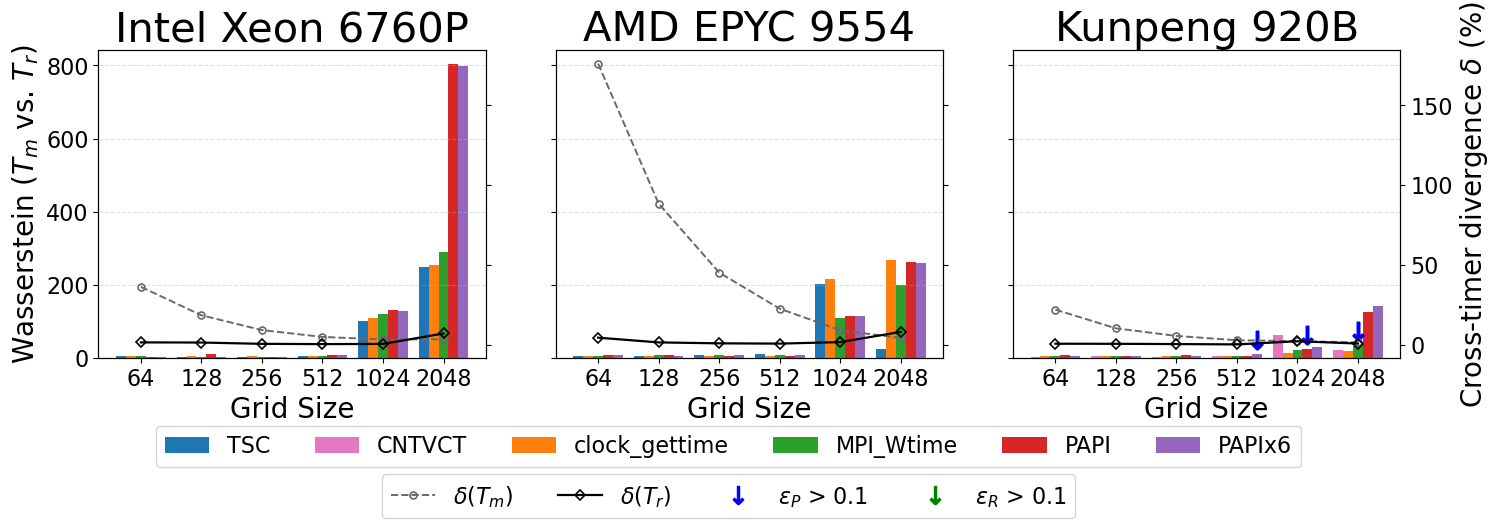

[WD / divergence Tm->Tr + eps]  kernel=2D 5-Point Jacobi Stencil  cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2  hosts(L->R)=['Intel Xeon 6760P', 'AMD EPYC 9554', 'Kunpeng 920B']  ref_by_host={'Intel Xeon 6760P': 'tsc', 'AMD EPYC 9554': 'tsc', 'Kunpeng 920B': 'cntvct'}
kernel=jacobi2d5p h ost=cgnr6760pn2  before: [np.float64(94.98263212121432), np.float64(56.3478986902649), np.float64(28.792986330208997), np.float64(42.25399494196358), np.float64(16.355426112666855), np.float64(6.510697486860524)]  after: [np.float64(5.141778952808677), np.float64(5.7419385926247895), np.float64(6.66333371318073), np.float64(20.109006758665434), np.float64(11.958913485614561), np.float64(4.463941240967511)]
kernel=jacobi2d5p h ost=camd9554n1  before: [np.float64(524.8847358057984), np.float64(295.9237156164015), np.float64(154.12760374798677), np.float64(73.13559323450055), np.float64(7.1460995797587685), np.float64(2.8174467903604623)]  after: [np.float64(15.164848977031308), np.float64(7.

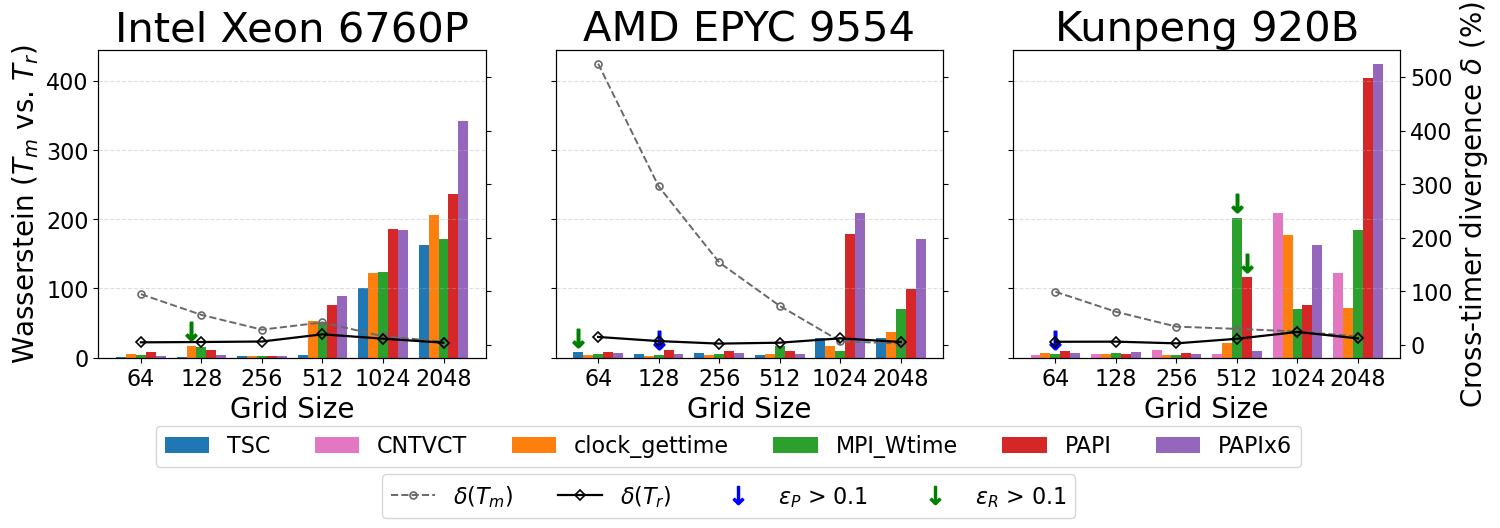

[WD / divergence Tm->Tr + eps]  kernel=TL F90 CG  cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2  hosts(L->R)=['Intel Xeon 6760P', 'AMD EPYC 9554', 'Kunpeng 920B']  ref_by_host={'Intel Xeon 6760P': 'tsc', 'AMD EPYC 9554': 'tsc', 'Kunpeng 920B': 'cntvct'}
kernel=tl_f90_cg_calc_w h ost=cgnr6760pn2  before: [np.float64(65.67646400227804), np.float64(36.75927514481939), np.float64(16.11388362659285), np.float64(5.111626835548545), np.float64(2.20215006023362), np.float64(0.8203622755153764)]  after: [np.float64(3.42592488226702), np.float64(2.5841924956563473), np.float64(2.292756007289137), np.float64(5.283240949011627), np.float64(3.7248899817017787), np.float64(1.5169502957955974)]
kernel=tl_f90_cg_calc_w h ost=camd9554n1  before: [np.float64(266.82504407352), np.float64(150.15330691114502), np.float64(72.02791176888617), np.float64(10.439255069927379), np.float64(3.2568299995210457), np.float64(1.4563751638110638)]  after: [np.float64(6.160798166221074), np.float64(2.8500726

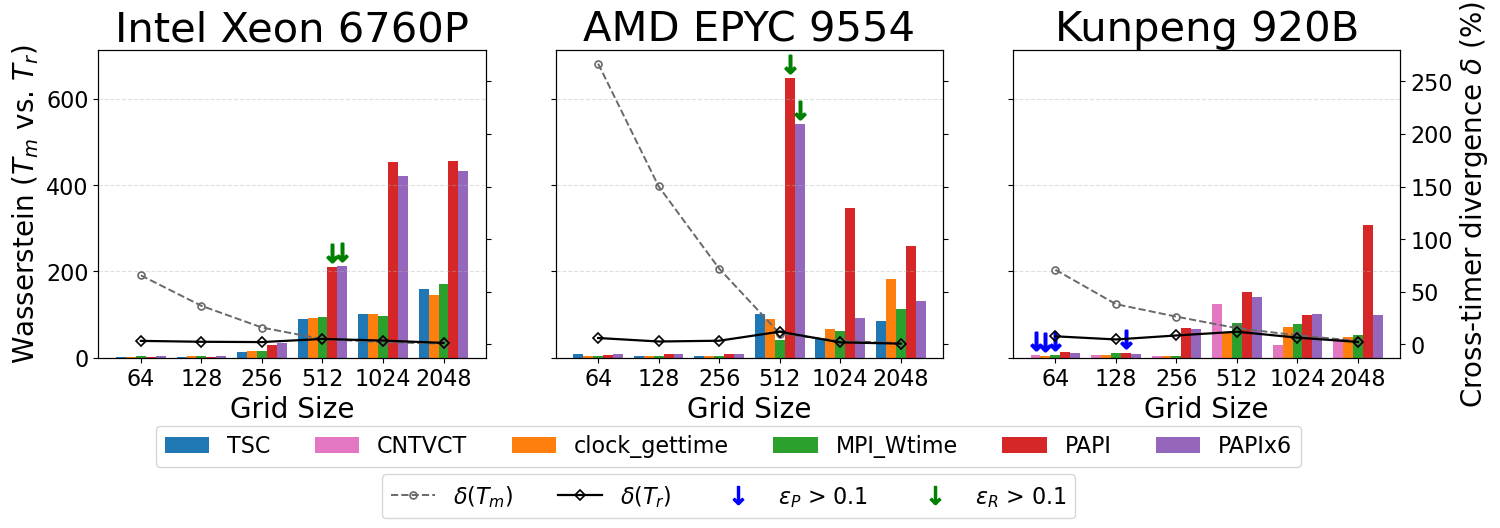

In [35]:
# Cross-timer divergence before (T_m) / after (T_r) + ep/er threshold indicators (stencil)
# divergence delta = mean_t WD(timer, ref) / mean(ref measured time);  ref: x86->tsc, ARM->cntvct.
# reduction = (sum WD_tm - sum WD_tr) / sum WD_tm  (deviation reduction ratio; column only).
from scipy.stats import wasserstein_distance
from matplotlib.lines import Line2D

REF_TIMER_BY_HOST = {'cgnr6760pn2': 'tsc', 'camd9554n1': 'tsc', 'c920bn3': 'cntvct'}

# ---- thresholds (tune by hand) ----
EP_THRESHOLD = 0.1  # eps_P over this -> flag
ER_THRESHOLD = 0.1  # eps_R over this -> flag

# ---- fonts (tune by hand) ----
TITLE_FONTSIZE = 30
AXIS_LABEL_FONTSIZE = 20
TICK_FONTSIZE = 16
LEGEND_FONTSIZE = 16
ARROW_FONTSIZE = 13
# legend vertical offsets (more negative = lower); timer legend above, divergence legend below
TIMER_LEGEND_Y = 0.07
DIV_LEGEND_Y = -0.04


def _wd_seq(a, b):
    if a is None or b is None:
        return np.nan
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    return wasserstein_distance(a, b) if (a.size and b.size) else np.nan


def divergence_table(src, group_keys):
    """Cross-timer divergence before (TM) and after (TR), plus deviation reduction ratio.
    delta = mean over non-ref timers of WD(timer, ref) / mean(ref measured time); same base
    for before/after so the two levels are comparable. reduction = (sum_tm - sum_tr)/sum_tm."""
    rows = []
    for gv, g in src.groupby(group_keys):
        gd = dict(zip(group_keys, gv if isinstance(gv, tuple) else (gv,)))
        ref_timer = REF_TIMER_BY_HOST.get(gd['host'])
        ref = g[g['timer'] == ref_timer]
        if ref.empty:
            continue
        ref = ref.iloc[0]
        ref_tm = np.asarray(ref['tm_seq'], dtype=float) if ref['tm_seq'] is not None else None
        base = float(np.mean(ref_tm)) if (ref_tm is not None and ref_tm.size) else np.nan
        tm_ds, tr_ds = [], []
        for _, r in g.iterrows():
            if r['timer'] == ref_timer:
                continue
            d_tm = _wd_seq(r['tm_seq'], ref['tm_seq'])
            d_tr = _wd_seq(r['tr_seq'], ref['tr_seq'])
            if np.isfinite(d_tm):
                tm_ds.append(d_tm)
            if np.isfinite(d_tr):
                tr_ds.append(d_tr)
        s_tm = float(np.sum(tm_ds)) if tm_ds else np.nan
        s_tr = float(np.sum(tr_ds)) if tr_ds else np.nan
        gd['reduction'] = (s_tm - s_tr) / s_tm if (np.isfinite(s_tm) and s_tm > 0) else np.nan
        if gd['reduction'] is np.nan:
            print(f"divergence_table group {gv}: base={base} sum_tm={s_tm} sum_tr={s_tr} reduction={gd['reduction']}")
        if int(gd['size']) == 256:
            print(f"divergence_table group {gv}: base={base} sum_tm={s_tm} sum_tr={s_tr} reduction={gd['reduction']}")

        if np.isfinite(base) and base > 0:
            gd['d_before'] = (np.mean(tm_ds) / base) if tm_ds else np.nan
            gd['d_after'] = (np.mean(tr_ds) / base) if tr_ds else np.nan
        else:
            gd['d_before'] = gd['d_after'] = np.nan
        rows.append(gd)
    return pd.DataFrame(rows)


def _flag_color(ep_v, er_v):
    ep_hi = np.isfinite(ep_v) and ep_v > EP_THRESHOLD
    er_hi = np.isfinite(er_v) and er_v > ER_THRESHOLD
    if ep_hi and er_hi:
        return 'red'
    if ep_hi:
        return 'blue'
    if er_hi:
        return 'green'
    return None


metric_bar = 'wd'
div_df = divergence_table(df, ['kernel', 'host', 'size', 'nsampRatio'])

plot_df = df.copy()
plot_df['timer_label'] = plot_df['timer'].map(TIMER_LABELS).fillna(plot_df['timer'])
plot_df['kernel_label'] = plot_df['kernel'].map(KERNEL_LABELS).fillna(plot_df['kernel'])
plot_df['size_str'] = plot_df['size'].astype(str)
size_order = [str(x) for x in sorted(plot_df['size'].unique())]
plot_df['size_str'] = pd.Categorical(plot_df['size_str'], categories=size_order, ordered=True)

hosts = [host_from_data_folder(p) for p in DATA_FOLDERS]
kernels = sorted(plot_df['kernel'].dropna().unique())

for kernel in kernels:
    kernel_df = plot_df[plot_df['kernel'] == kernel].copy()
    if kernel_df.empty:
        continue
    dk = div_df[div_df['kernel'] == kernel]
    kernel_label = kernel_df['kernel_label'].iloc[0]
    refs = {HOST_LABELS.get(h, h): REF_TIMER_BY_HOST.get(h) for h in hosts}
    print(f'[WD / divergence Tm->Tr + eps]  kernel={kernel_label}  {SHUFFLE_LABEL}  hosts(L->R)={[HOST_LABELS.get(h, h) for h in hosts]}  ref_by_host={refs}')

    gmax = np.nanmax(kernel_df[metric_bar].to_numpy(dtype=float)) if len(kernel_df) else 1.0
    if not np.isfinite(gmax) or gmax <= 0:
        gmax = 1.0
    arrow_dy = 0.05 * gmax

    fig, axes = plt.subplots(1, len(hosts), figsize=(5.6 * len(hosts), 4.4), sharey=True, constrained_layout=False)
    if len(hosts) == 1:
        axes = [axes]

    right_axes = []
    bar_handles = {}          # keyed by timer -> handle, for ordered legend
    before_handle = after_handle = None
    any_red = False
    for ax1, host in zip(axes, hosts):
        host_df = kernel_df[kernel_df['host'] == host]
        ref_timer = REF_TIMER_BY_HOST.get(host)
        ax1.set_title(HOST_LABELS.get(host, host), fontsize=TITLE_FONTSIZE)
        ax1.set_xlabel('Grid Size', fontsize=AXIS_LABEL_FONTSIZE)
        ax1.set_ylabel(r'Wasserstein ($T_m$ vs. $T_r$)' if ax1 is axes[0] else '', fontsize=AXIS_LABEL_FONTSIZE)
        ax1.grid(axis='y', linestyle='--', alpha=0.4)

        ax2 = ax1.twinx()
        right_axes.append(ax2)

        if host_df.empty:
            ax1.text(0.5, 0.5, 'no data', ha='center', va='center', transform=ax1.transAxes)
            ax1.set_xticks([])
            ax2.set_yticks([])
            continue

        timers = sorted(host_df['timer'].unique(), key=timer_sort_key)
        x = np.arange(len(size_order))
        width = 0.82 / max(len(timers), 1)
        for i, timer in enumerate(timers):
            sub = host_df[host_df['timer'] == timer].set_index('size_str').reindex(size_order)
            offset = (i - (len(timers) - 1) / 2) * width
            heights = sub[metric_bar].to_numpy(dtype=float)
            b = ax1.bar(x + offset, heights, width=width, label=timer_label(timer), color=TIMER_COLORS.get(timer))
            bar_handles.setdefault(timer, b)
            ep_arr = sub['ep'].to_numpy(dtype=float)
            er_arr = sub['er'].to_numpy(dtype=float)
            for j in range(len(size_order)):
                h = heights[j]
                if not np.isfinite(h):
                    continue
                c = _flag_color(ep_arr[j], er_arr[j])
                if c is None:
                    continue
                if c == 'red':
                    any_red = True
                ax1.plot(x[j] + offset, h + arrow_dy, marker=r'$\downarrow$', linestyle='None',
                         color=c, markersize=ARROW_FONTSIZE, markeredgewidth=1.4, zorder=6, clip_on=False)

        # x ticks: horizontal, with the ref timer's (tsc/cntvct) TM p25/p75 on a second line
        xticklabels = []
        for s in size_order:
            rr = host_df[(host_df['timer'] == ref_timer) & (host_df['size'] == int(s))]
            if len(rr) and rr.iloc[0]['tm_seq'] is not None:
                seq = np.asarray(rr.iloc[0]['tm_seq'], dtype=float)
                p25, p75 = np.quantile(seq, 0.25), np.quantile(seq, 0.75)
                # xticklabels.append(f'{s}\n({p25:.0f}/{p75:.0f})')
                xticklabels.append(f'{s}')
            else:
                xticklabels.append(f'{s}')
        ax1.set_xticks(x)
        ax1.set_xticklabels(xticklabels, rotation=0, fontsize=TICK_FONTSIZE)
        ax1.tick_params(axis='y', labelsize=TICK_FONTSIZE)

        dh = dk[dk['host'] == host]
        db = dh.groupby('size')['d_before'].mean()
        da = dh.groupby('size')['d_after'].mean()
        before_vals = [100.0 * db.get(int(s), np.nan) for s in size_order]
        after_vals = [100.0 * da.get(int(s), np.nan) for s in size_order]
        lb, = ax2.plot(x, before_vals, marker='o', markersize=5, markerfacecolor='none', markeredgewidth=1.2, color='dimgray', linestyle='--', linewidth=1.4)
        la, = ax2.plot(x, after_vals, marker='D', markersize=5, markerfacecolor='none', markeredgewidth=1.2, color='black', linestyle='-', linewidth=1.6)

        print(f"kernel={kernel} h ost={host}  before: {before_vals}  after: {after_vals}")

        before_handle, after_handle = lb, la
        ax2.tick_params(axis='y', labelsize=TICK_FONTSIZE)

    left_lims = [ax.get_ylim() for ax in axes]
    left_ylim = (min(lo for lo, hi in left_lims), max(hi for lo, hi in left_lims))
    for ax in axes:
        ax.set_ylim(left_ylim)
    rlims = [ax.get_ylim() for ax in right_axes]
    rylim = (min(lo for lo, hi in rlims), max(hi for lo, hi in rlims))
    for j, ax in enumerate(right_axes):
        ax.set_ylim(rylim)
        if j == len(right_axes) - 1:
            ax.set_ylabel(r'Cross-timer divergence $\delta$ (%)', fontsize=AXIS_LABEL_FONTSIZE)
        else:
            ax.set_yticklabels([])

    # timer legend (ordered by timer_sort_key), placed at the bottom
    ordered_timers = sorted(bar_handles, key=timer_sort_key)
    fig.legend([bar_handles[t] for t in ordered_timers], [timer_label(t) for t in ordered_timers],
               ncol=min(6, max(1, len(ordered_timers))), fontsize=LEGEND_FONTSIZE,
               loc='upper center', bbox_to_anchor=(0.5, TIMER_LEGEND_Y), frameon=True)

    # divergence legend (below the timer legend): delta lines + eps arrows (+both only if drawn)
    arrow_proxies = [
        Line2D([0], [0], marker=r'$\downarrow$', linestyle='None', color='blue', markersize=ARROW_FONTSIZE, label=fr'$\epsilon_P$ > {EP_THRESHOLD:g}'),
        Line2D([0], [0], marker=r'$\downarrow$', linestyle='None', color='green', markersize=ARROW_FONTSIZE, label=fr'$\epsilon_R$ > {ER_THRESHOLD:g}'),
    ]
    if any_red:
        arrow_proxies.append(Line2D([0], [0], marker=r'$\downarrow$', linestyle='None', color='red', markersize=ARROW_FONTSIZE, label='both'))
    div_handles = [before_handle, after_handle] + arrow_proxies
    div_labels = [r'$\delta(T_m)$', r'$\delta(T_r)$'] + [p.get_label() for p in arrow_proxies]
    fig.legend(div_handles, div_labels, ncol=min(5, len(div_labels)), fontsize=LEGEND_FONTSIZE,
               loc='upper center', bbox_to_anchor=(0.5, DIV_LEGEND_Y), frameon=True)

    fig.subplots_adjust(bottom=0.20, top=0.90, wspace=0.18)

    if SAVE_FIG:
        OUT_DIR.mkdir(parents=True, exist_ok=True)
        out = OUT_DIR / f'{kernel}_{SHUFFLE_LABEL}_wd_div_eper_by_host.png'
        fig.savefig(out, dpi=220, bbox_inches='tight')
        print(out)

    plt.show()

In [36]:
tmp_df = df.join(div_df, lsuffix="_left", rsuffix="_right",how='left').sort_values(['reduction'],ascending=False)[['host_left','size_left','kernel_left','ep','er','reduction']]
tmp_df[tmp_df['size_left'] == 256]

,host_left,size_left,kernel_left,ep,er,reduction
9,cgnr6760pn2,256,gs2d5p,0.000538,0.002474,0.972501
3,cgnr6760pn2,256,gs2d5p,0.000000,0.004702,0.955452
27,cgnr6760pn2,256,gs2d5p,0.000142,0.002527,0.938988
15,cgnr6760pn2,256,gs2d5p,0.000142,0.002558,0.937060
21,cgnr6760pn2,256,gs2d5p,0.000000,0.003038,0.609770
33,cgnr6760pn2,256,jacobi2d5p,0.010393,0.007140,0.524092
39,cgnr6760pn2,256,jacobi2d5p,0.001595,0.005803,0.216648
51,cgnr6760pn2,256,jacobi2d5p,0.011679,0.006968,-0.033573
45,cgnr6760pn2,256,jacobi2d5p,0.000241,0.005355,-0.163487
183,c920bn3,256,gs2d5p,0.000000,0.002495,NaN


In [37]:
# Per-kernel: grid sizes where ALL hosts' ALL timers satisfy ep <= EP_THRESHOLD and er <= ER_THRESHOLD.
print(f'Qualifying grid sizes (every host/timer has ep <= {EP_THRESHOLD:g} and er <= {ER_THRESHOLD:g}):')
for kernel in sorted(df['kernel'].dropna().unique()):
    kdf = df[df['kernel'] == kernel]
    good = []
    for size, sdf in kdf.groupby('size'):
        if (sdf['ep'] <= EP_THRESHOLD).all() and (sdf['er'] <= ER_THRESHOLD).all():
            good.append(int(size))
    print(f'  {KERNEL_LABELS.get(kernel, kernel)} ({kernel}): {sorted(good)}')

Qualifying grid sizes (every host/timer has ep <= 0.1 and er <= 0.1):
  2D 5-Point Gauss-Seidel (gs2d5p): [64, 128, 256]
  2D 5-Point Jacobi Stencil (jacobi2d5p): [256, 1024, 2048]
  TL F90 CG (tl_f90_cg_calc_w): [256, 1024, 2048]


# Filt Plot

In [38]:
entries['nsamp'].unique()

array([ 4309,   531, 10214,  1045,  2071,   275,  4484,   707,  8908,
        1221,  2248,   451,  4538,   716,  9144,  1229,  2257,   459,
        4280,   526, 10074,  1039,  2064,   267,   532,  9933,  1046,
        2072,   276,  3812,   171,  8926,   310,   964,   101,  3628,
         358,  8717,   497,   889,   289,  3611,   367,  8692,   507,
         895,   298,  3169,   178,  8250,   328,   679,   103,  3784,
         174,  8874,   313,   894,   104,  7271,   288, 16472,   618,
        2013,   160,  7454,   476, 16651,   800,  2201,   348,  7481,
         488, 16678,   808,  2214,   355,  7227,   283, 16448,   606,
        2018,   156,  7298,   292, 16478,   620,  2026,   166,  4936,
         604, 12217,  1179,  2328,  5634,  1536, 11750,  2111,  3275,
        1241,  5852,  1753, 11735,  3492,  1458,  4919,   589, 11657,
        1164,  4983, 12246,  2329,  8041,   201, 19557,   342,   699,
         124,  7652,  1102, 18720,  1272,  1660,  1024,  7574,  1319,
       18488,  1491,

[FILT CDF]  kernel=2D 5-Point Gauss-Seidel  cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2  np=64  size=256  nsampRatio=0.5  hosts(L->R)=['Intel Xeon 6760P', 'AMD EPYC 9554', 'Kunpeng 920B']
host=cgnr6760pn2 timer=tsc  tm_median=947.00 ns  tr_median=913.00 ns
host=cgnr6760pn2 timer=cgt  tm_median=953.50 ns  tr_median=914.50 ns
host=cgnr6760pn2 timer=wtime  tm_median=949.52 ns  tr_median=906.52 ns
host=cgnr6760pn2 timer=papi  tm_median=1110.80 ns  tr_median=907.80 ns
host=cgnr6760pn2 timer=papix6  tm_median=1118.82 ns  tr_median=908.82 ns
host=camd9554n1 timer=tsc  tm_median=757.88 ns  tr_median=737.88 ns
host=camd9554n1 timer=cgt  tm_median=764.88 ns  tr_median=734.88 ns
host=camd9554n1 timer=wtime  tm_median=764.87 ns  tr_median=733.87 ns
host=camd9554n1 timer=papi  tm_median=1366.72 ns  tr_median=735.72 ns
host=camd9554n1 timer=papix6  tm_median=1507.52 ns  tr_median=746.52 ns
host=c920bn3 timer=cntvct  tm_median=1415.50 ns  tr_median=1365.50 ns
host=c920bn3 timer=cgt  tm_

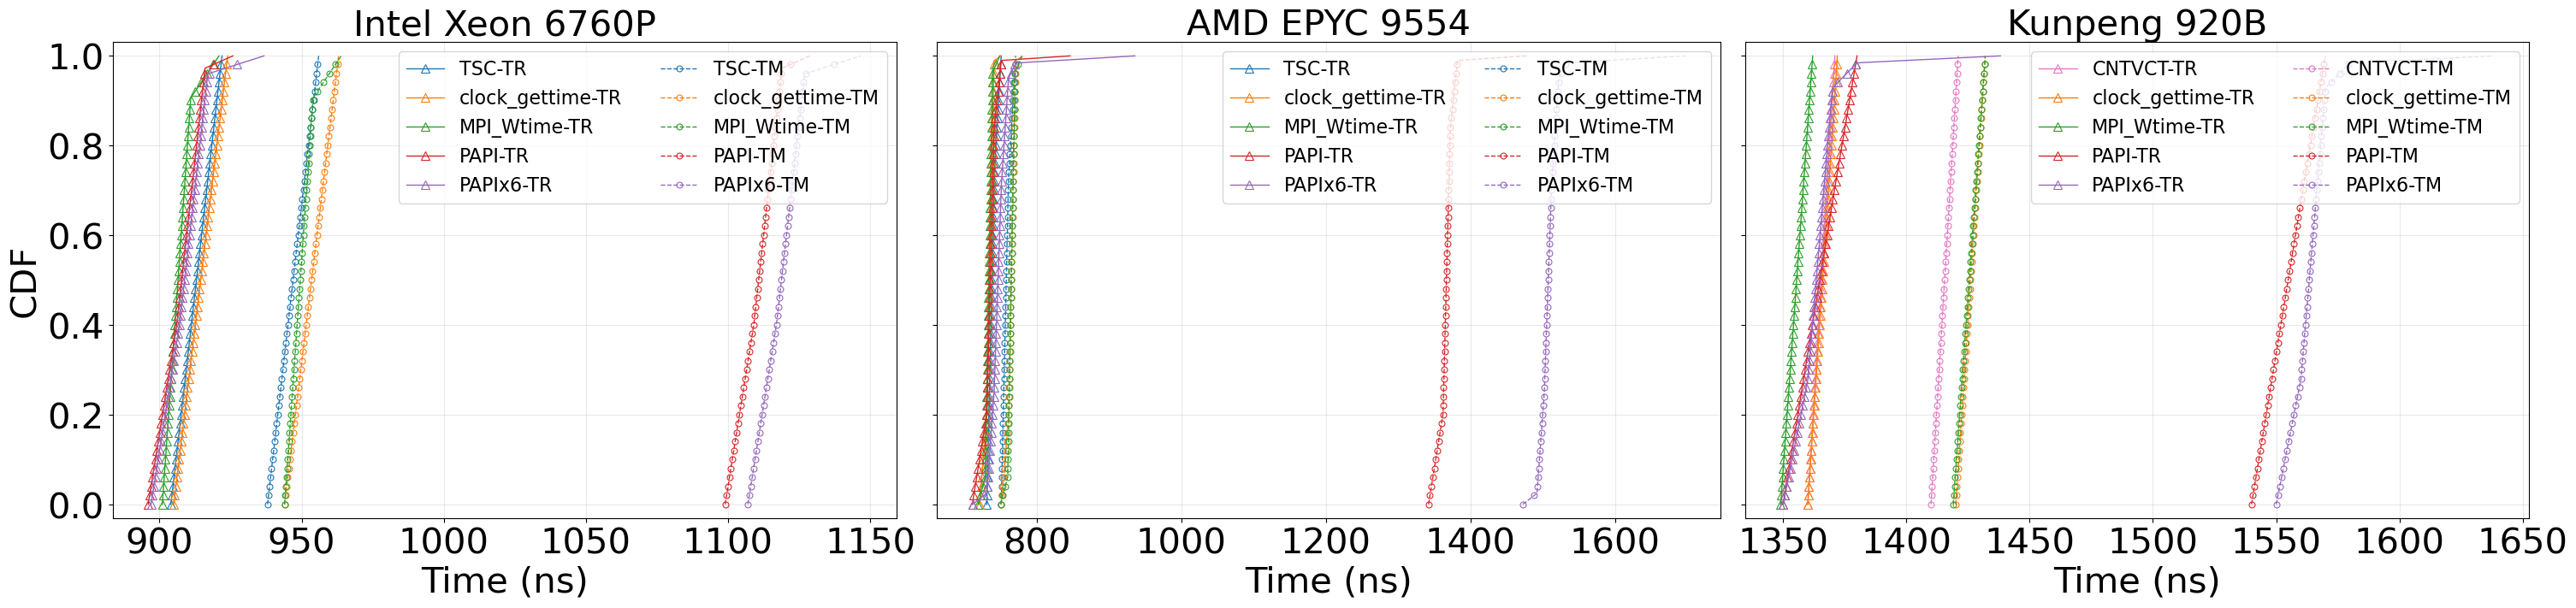

[FILT CDF]  kernel=2D 5-Point Jacobi Stencil  cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2  np=64  size=256  nsampRatio=0.5  hosts(L->R)=['Intel Xeon 6760P', 'AMD EPYC 9554', 'Kunpeng 920B']
host=cgnr6760pn2 timer=tsc  tm_median=300.11 ns  tr_median=268.05 ns
host=cgnr6760pn2 timer=cgt  tm_median=283.11 ns  tr_median=245.06 ns
host=cgnr6760pn2 timer=wtime  tm_median=285.11 ns  tr_median=244.05 ns
host=cgnr6760pn2 timer=papi  tm_median=452.87 ns  tr_median=250.87 ns
host=cgnr6760pn2 timer=papix6  tm_median=461.51 ns  tr_median=251.51 ns
host=camd9554n1 timer=tsc  tm_median=217.72 ns  tr_median=197.72 ns
host=camd9554n1 timer=cgt  tm_median=228.56 ns  tr_median=209.05 ns
host=camd9554n1 timer=wtime  tm_median=232.97 ns  tr_median=202.15 ns
host=camd9554n1 timer=papi  tm_median=823.25 ns  tr_median=201.25 ns
host=camd9554n1 timer=papix6  tm_median=966.55 ns  tr_median=205.55 ns
host=c920bn3 timer=cntvct  tm_median=243.79 ns  tr_median=218.63 ns
host=c920bn3 timer=cgt  tm_medi

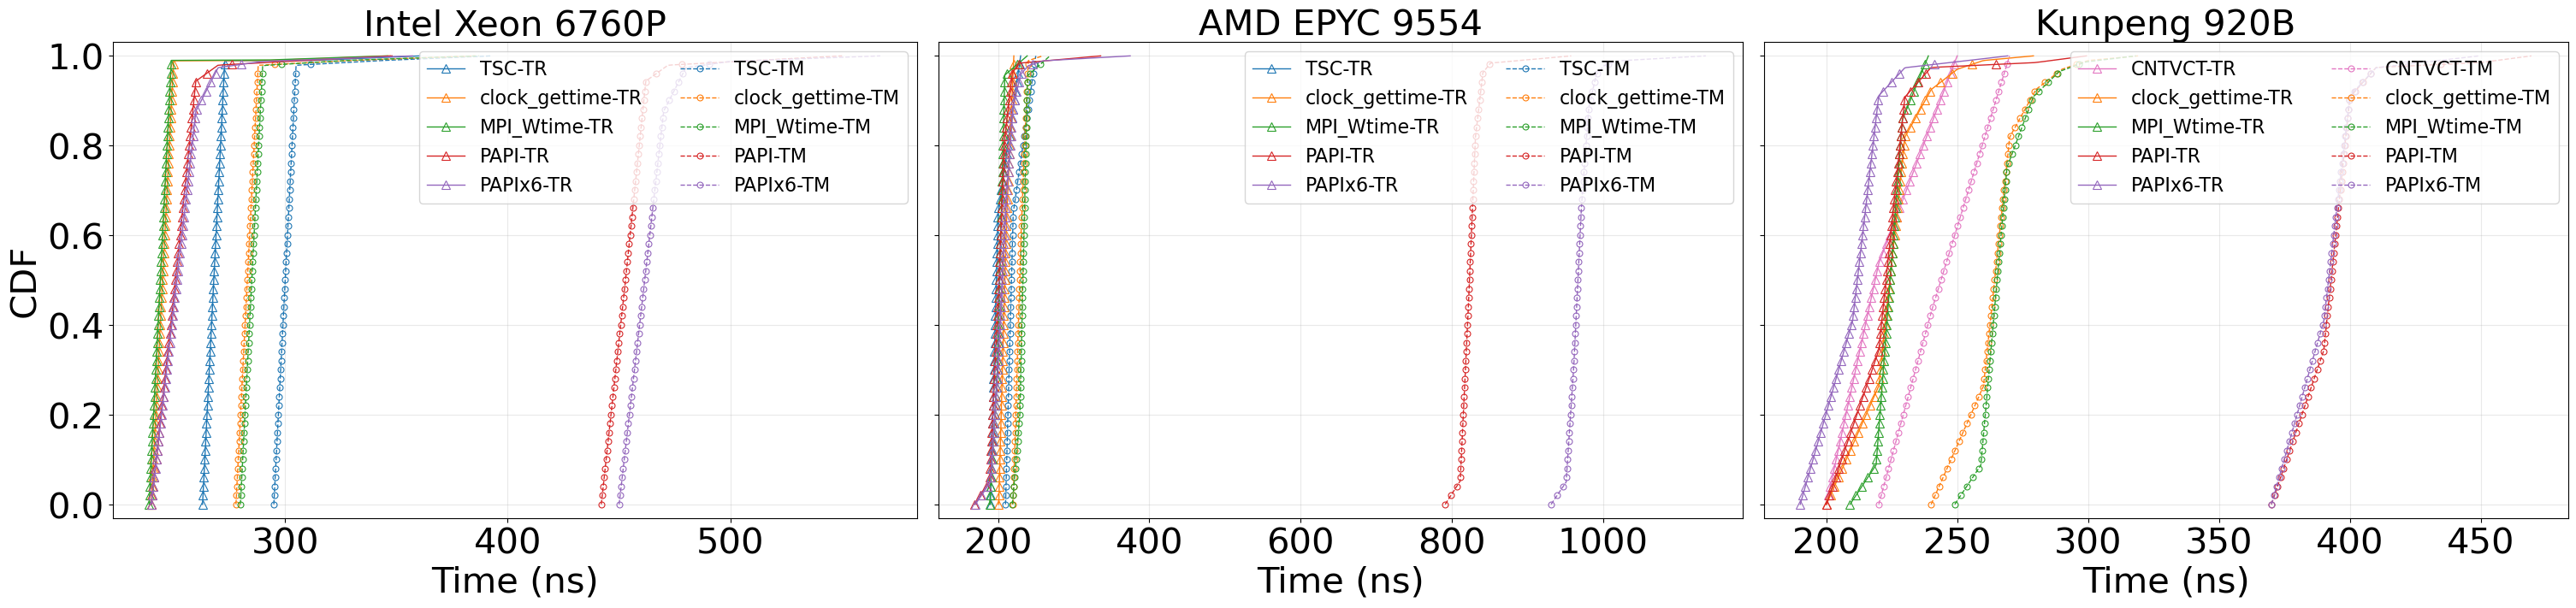

[FILT CDF]  kernel=TL F90 CG  cgnr6760pn2-shuffle2_camd9554n1-shuffle2_c920bn3-shuffle2  np=64  size=256  nsampRatio=0.5  hosts(L->R)=['Intel Xeon 6760P', 'AMD EPYC 9554', 'Kunpeng 920B']
host=cgnr6760pn2 timer=tsc  tm_median=551.91 ns  tr_median=517.22 ns
host=cgnr6760pn2 timer=cgt  tm_median=562.12 ns  tr_median=515.40 ns
host=cgnr6760pn2 timer=wtime  tm_median=564.39 ns  tr_median=515.52 ns
host=cgnr6760pn2 timer=papi  tm_median=728.58 ns  tr_median=508.86 ns
host=cgnr6760pn2 timer=papix6  tm_median=734.93 ns  tr_median=511.77 ns
host=camd9554n1 timer=tsc  tm_median=410.89 ns  tr_median=389.33 ns
host=camd9554n1 timer=cgt  tm_median=407.41 ns  tr_median=375.62 ns
host=camd9554n1 timer=wtime  tm_median=416.87 ns  tr_median=381.77 ns
host=camd9554n1 timer=papi  tm_median=998.99 ns  tr_median=367.99 ns
host=camd9554n1 timer=papix6  tm_median=1004.14 ns  tr_median=372.14 ns
host=c920bn3 timer=cntvct  tm_median=562.86 ns  tr_median=519.09 ns
host=c920bn3 timer=cgt  tm_median=624.76 ns  t

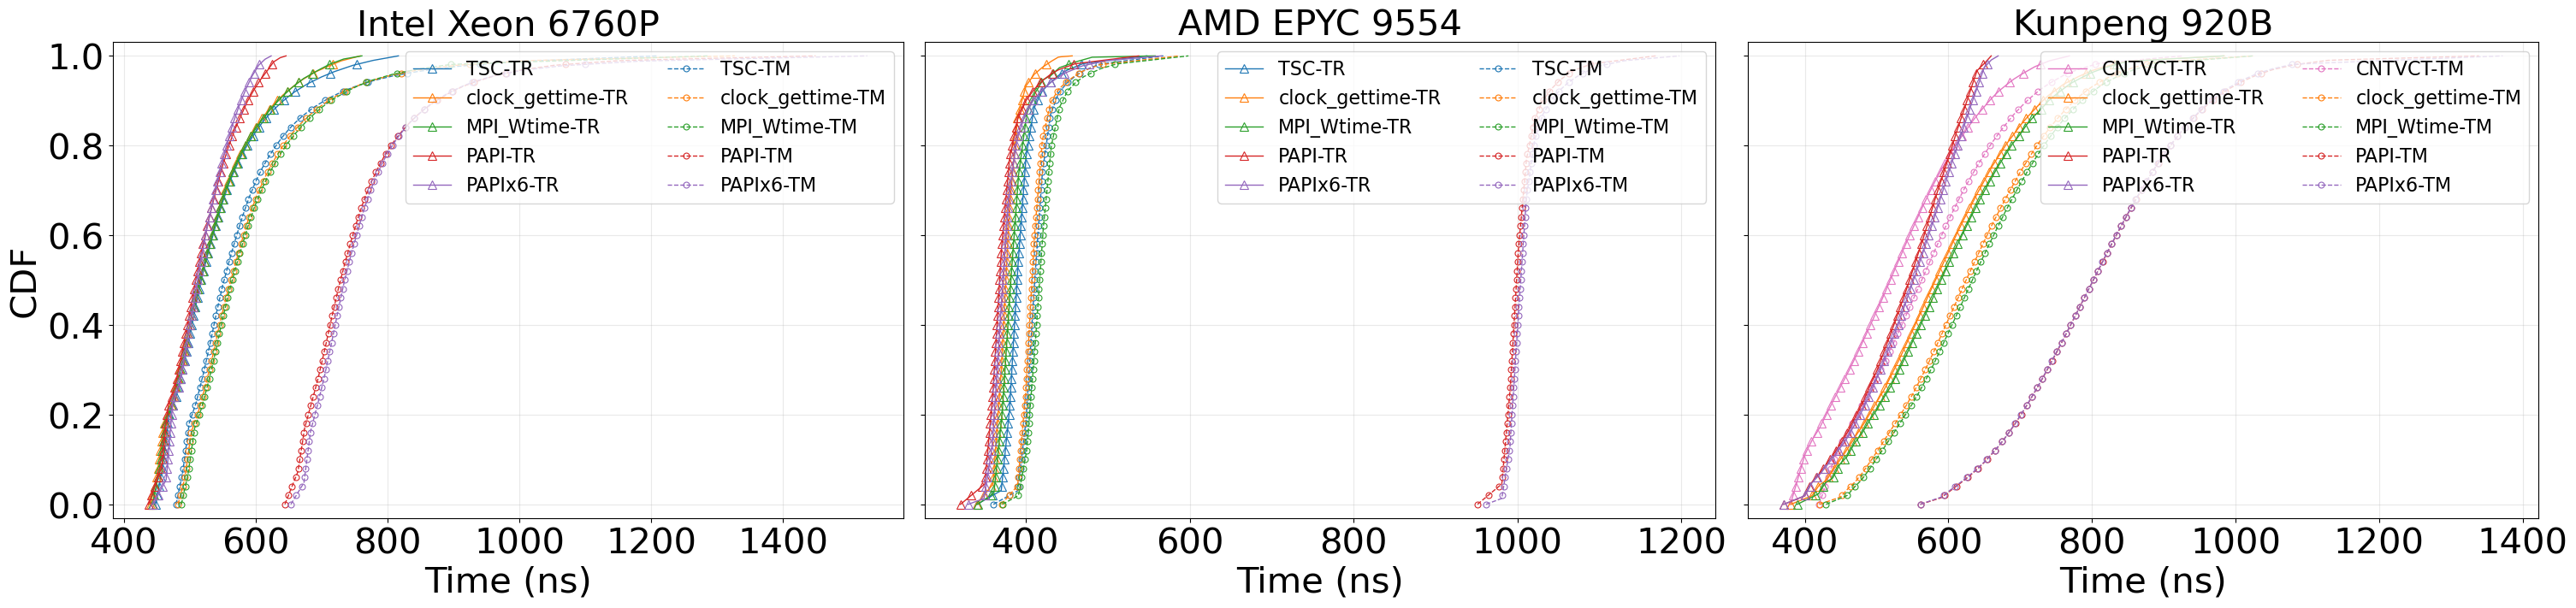

In [39]:
# ---- font sizes (tune here) ----
FILT_TITLE_FONTSIZE  = 30
FILT_LABEL_FONTSIZE  = 30
FILT_TICK_FONTSIZE   = 30
FILT_LEGEND_FONTSIZE = 16

plot_df = df[df['timer'] != 'likwid'].copy()

if plot_df.empty:
    raise RuntimeError('No entries with tr_seq/tm_seq to plot')

if SAVE_FIG:
    OUT_DIR.mkdir(parents=True, exist_ok=True)

hosts = [host_from_data_folder(p) for p in DATA_FOLDERS]


def seq_ecdf(seq):
    """ECDF (x, y) from a sample array, clipped to QUANTILE_DROP."""
    s = np.sort(np.asarray(seq, dtype=float))
    n = s.size
    if n == 0:
        return s, s
    y = (np.arange(n) + 0.5) / n
    keep = y <= QUANTILE_DROP
    return s[keep], y[keep]


def _ordered_tr_tm(ax):
    """Legend handles ordered so each row pairs timer-TR, timer-TM (ncol=2, column-major)."""
    h, l = ax.get_legend_handles_labels()
    tr = [(hh, ll) for hh, ll in zip(h, l) if ll.endswith('-TR')]
    tm = [(hh, ll) for hh, ll in zip(h, l) if ll.endswith('-TM')]
    ordered = tr + tm
    return [hh for hh, ll in ordered], [ll for hh, ll in ordered]


for (kernel, np_val, size, nsamp_ratio), group_all in plot_df.groupby(['kernel', 'np', 'size', 'nsampRatio'], sort=True):
    if kernel == 'jacobi2d5p' and size != 256:
        continue
    elif kernel == 'gs2d5p' and size != 256:
        continue
    elif kernel == 'tl_f90_cg_calc_w' and size != 256:
        continue
    
    print(f'[FILT CDF]  kernel={KERNEL_LABELS.get(kernel, kernel)}  {SHUFFLE_LABEL}  np={np_val}  size={size}  nsampRatio={nsamp_ratio}  hosts(L->R)={[HOST_LABELS.get(h, h) for h in hosts]}')
    fig, axes = plt.subplots(1, len(hosts), figsize=(10.0 * len(hosts), 7), sharey=True, constrained_layout=True)
    if len(hosts) == 1:
        axes = [axes]

    for ax, host in zip(axes, hosts):
        group = group_all[group_all['host'] == host].sort_values('timer', key=lambda s: s.map(timer_sort_key))

        for _, row in group.iterrows():
            timer = row['timer']
            color = TIMER_COLORS.get(timer)
            label = timer_label(timer)

            if row['tm_seq'] is None or row['tr_seq'] is None:
                continue

            tm_x, tm_y = seq_ecdf(row['tm_seq'])
            tr_x, tr_y = seq_ecdf(row['tr_seq'])

            row['tm_median'] = np.median(row['tm_seq'])
            row['tr_median'] = np.median(row['tr_seq'])
            print(f"host={row['host']} timer={row['timer']}  tm_median={row['tm_median']:.2f} ns  tr_median={row['tr_median']:.2f} ns")

            tm_me = max(1, len(tm_x) // 50)
            tr_me = max(1, len(tr_x) // 50)

            ax.plot(tm_x, tm_y, label=f'{label}-TM', color=color, linestyle='--', linewidth=1.0, marker='.', markevery=tm_me, markersize=10, markerfacecolor='none', markeredgewidth=0.8)
            ax.plot(tr_x, tr_y, label=f'{label}-TR', color=color, linestyle='-', linewidth=1.0, marker='^', markevery=tr_me, markersize=7, markerfacecolor='none', markeredgewidth=0.8)

        ax.set_title(f"{HOST_LABELS.get(host, host)}", fontsize=FILT_TITLE_FONTSIZE)
        ax.set_xlabel('Time (ns)', fontsize=FILT_LABEL_FONTSIZE)
        ax.set_ylim(-0.03, QUANTILE_DROP + 0.03)
        ax.grid(True, alpha=0.28)
        ax.tick_params(axis='both', labelsize=FILT_TICK_FONTSIZE)
        oh, ol = _ordered_tr_tm(ax)
        if oh:
            ax.legend(oh, ol, ncol=2, fontsize=FILT_LEGEND_FONTSIZE, loc='upper right')

    for ax in axes:
        ax.set_ylim(-0.03, QUANTILE_DROP + 0.03)

    axes[0].set_ylabel('CDF', fontsize=FILT_LABEL_FONTSIZE)

    if SAVE_FIG:
        out = OUT_DIR / f'{kernel}_{SHUFFLE_LABEL}_np{np_val}_size{size}_ratio{nsamp_ratio}_tm_tr_by_host.png'
        fig.savefig(out, dpi=220, bbox_inches='tight')
        print(out)

    plt.show()
